## Examples of custom functions

In this example notebook, you will find examples of custom functions to calculate specific parameters with the *process_file* function.  

In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join('..', '..', 'src')))
import pandas as pd

from processing import process_file

To use the function correctly, you just have to select the parameters you want in argument and then to return the new parameter you want to calculate.  
The parameters that you can select are presented in the API Documentation, in the section corresponding to GITT, ICI or HPPC Test depending on which one you want to analyze.  

For the first example, we want to calculate the DCIR after 1 second for a GITT Test.  
We need to select in argument:
- t0: The time just before the start of the pulse
- Voltage: The voltage curve interpolation
- Ipulse: The pulse mean current

The formula is: DCIR = (Voltage(t0 + 1) - Voltage(t0)) / Ipulse  

Once defined, the function has to be part of the *process_file()* arguments as a list of functions. Here the list will only contain this function, but you can add as many as you need. The result is then available on the result DataFrame.

File : GITT_AG4_S_1577.parquet
Length : 20862255
Preprocessing Time : 128s
Find Test Time : 172s
Test : GITT ; Length : 20769192
       Pulse  Cycle State    TestTime       SOC       OCV    Ipulse  \
Pulse      0      1     D    46801.00  1.000000  2.484417 -0.043325   
Pulse      1      1     D    53999.98  0.980011  0.575001 -0.043325   
Pulse      2      1     D    61199.98  0.960011  0.379431 -0.043325   
Pulse      3      1     D    68399.98  0.940010  0.272730 -0.043324   
Pulse      4      1     D    75599.98  0.920010  0.216829 -0.043325   
...      ...    ...   ...         ...       ...       ...       ...   
Pulse    391      4     C  2692799.98  0.880001  0.216267  0.043323   
Pulse    392      4     C  2699099.98  0.900001  0.217590  0.043323   
Pulse    393      4     C  2705399.98  0.920000  0.219228  0.043324   
Pulse    394      4     C  2711699.98  0.940000  0.236643  0.043324   
Pulse    395      4     C  2717999.98  0.960000  0.332785  0.043324   

       Diffusion C

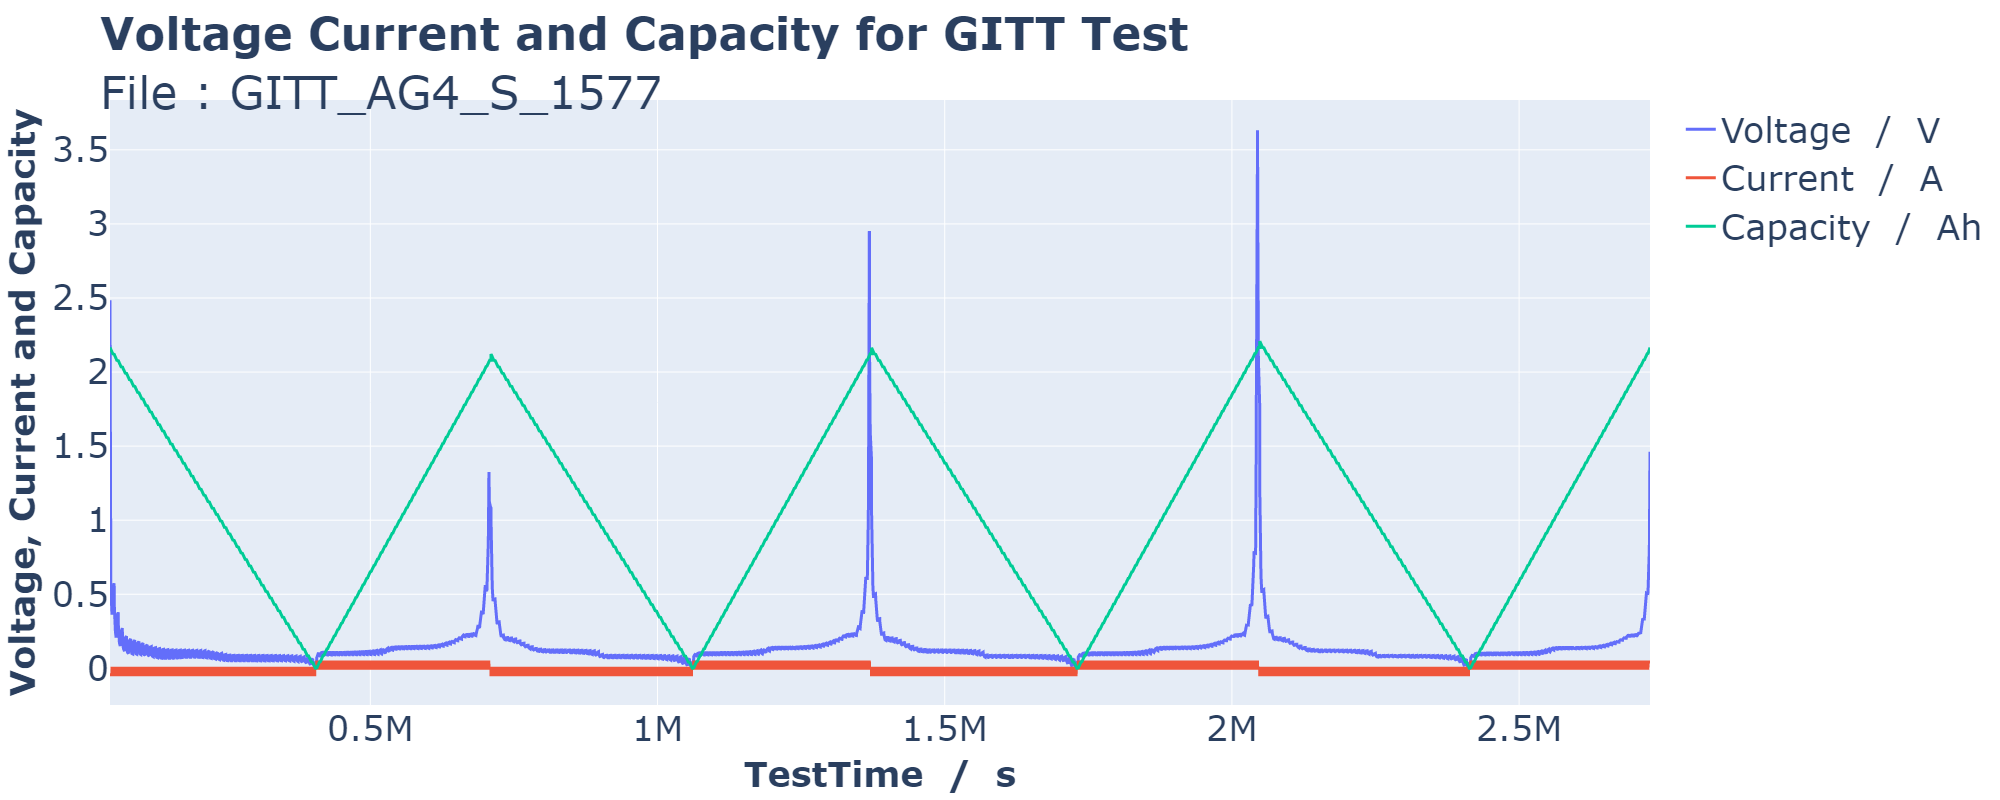

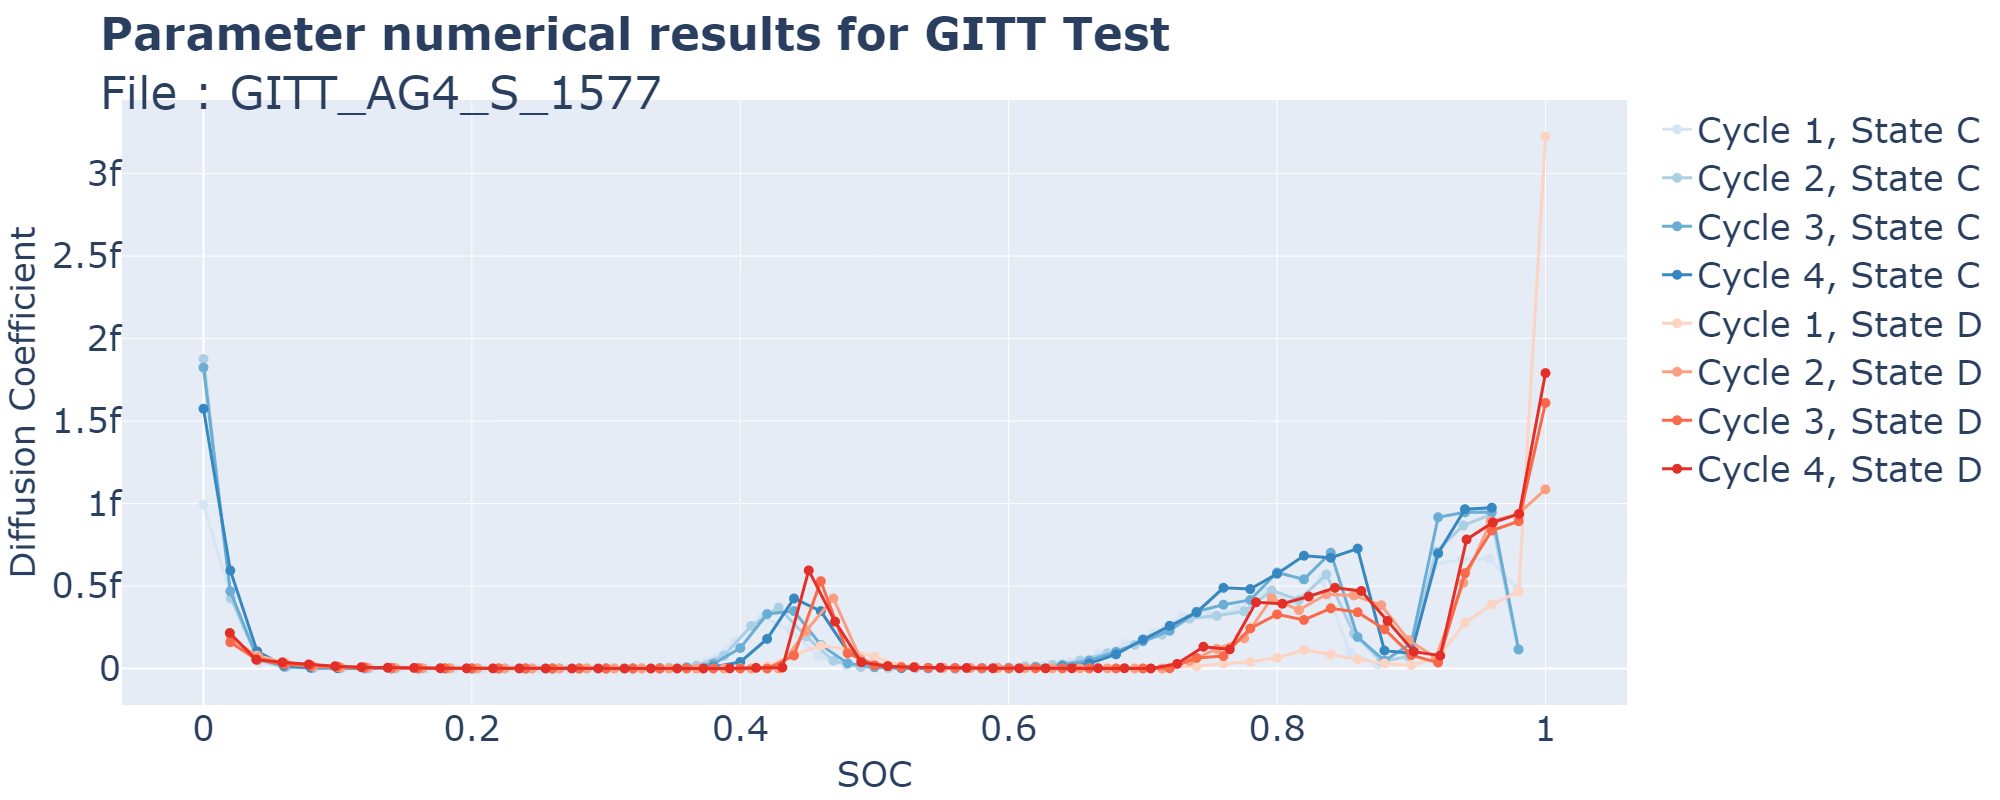

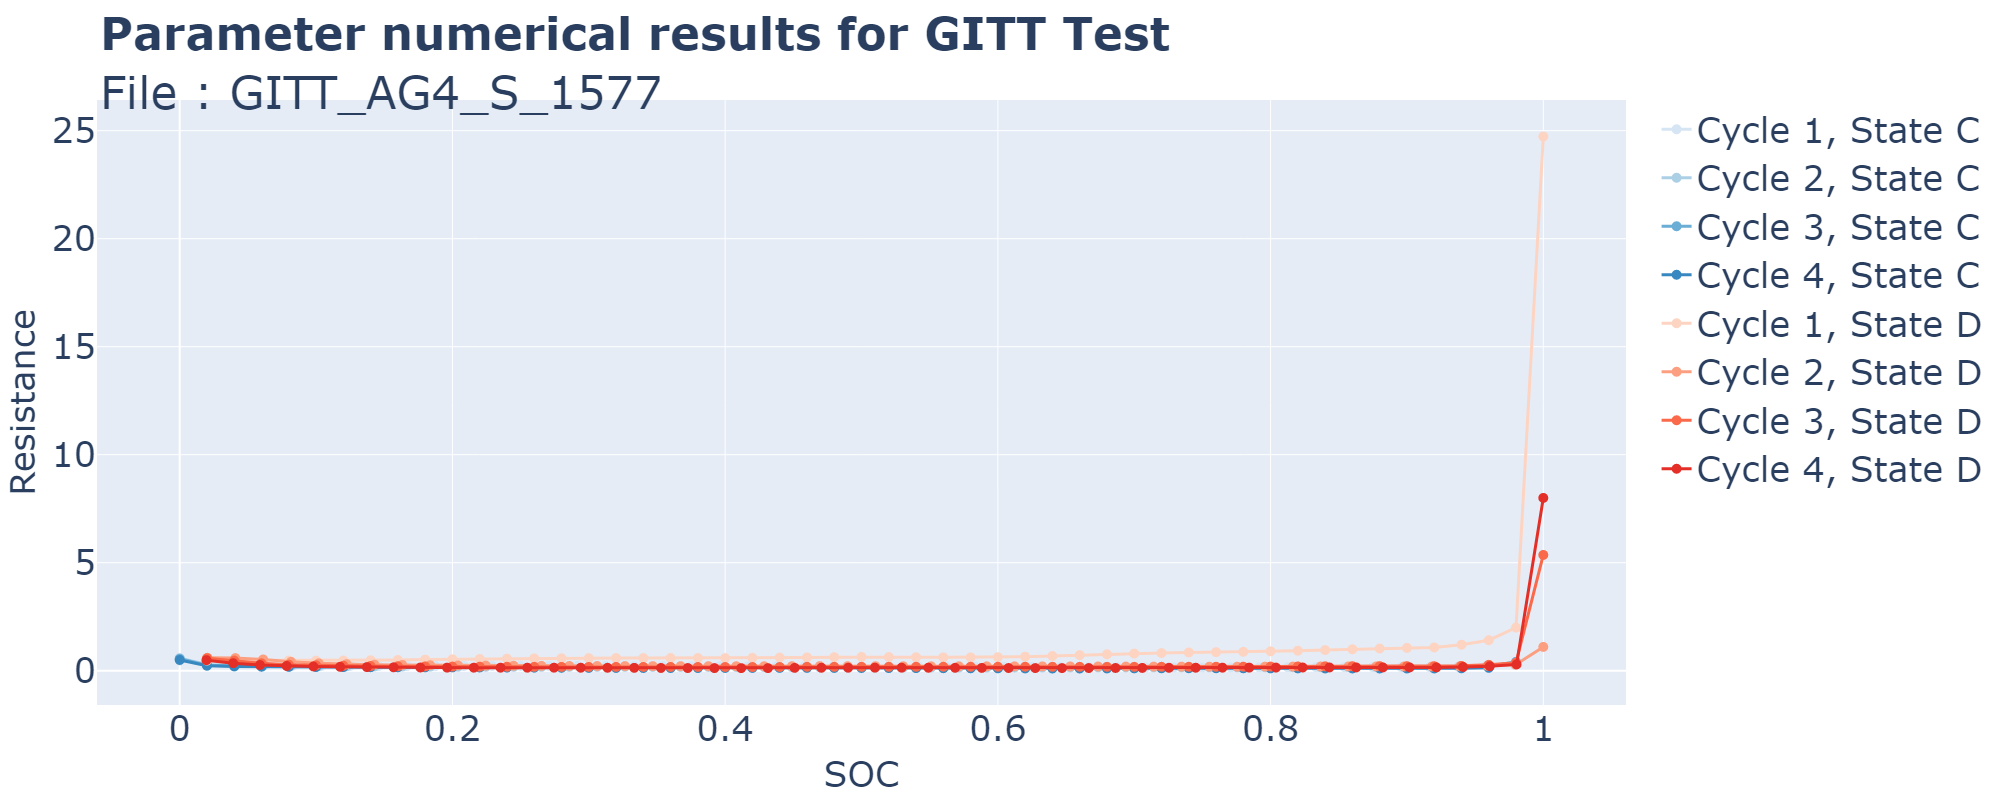

GITT Time : 75s
Total Time : 385s


In [ ]:
def my_example_func(Ipulse, Voltage, t0):
    DCIR = (Voltage(t0 + 1) - Voltage(t0)) / Ipulse
    return DCIR

file_path_GITT = os.path.join('example_file_GITT.parquet')

df, result_dict = process_file(file_path_GITT, my_func_list=[my_example_func], png=True)

For this second example, we want to calculate charge resistance for an HPPC Test.  
Once again, the parameters that you can select are presented in the API Documentation, in the HPPC section in this case.

We need to select in argument:
- V3: The time just before the start of the charging pulse
- V4: The time just after the start of the charging pulse
- Icharge: The charging pulse mean current

The formula is R_charge = (V4 - V3) / Icharge


File : HPPC_Samsung_16.csv
Length : 11183731
Preprocessing Time : 145s
Find Test Time : 0s
Test : CCCV ; Length : 59858
Test : HPPC ; Length : 26178
       Pulse  Cycle State   TestTime       SOC       OCV  R_charge  \
Pulse      1      2     D  2575167.0  0.900947  4.081708  0.052368   
Pulse      2      2     D  2577779.0  0.801184  4.024439  0.050853   
Pulse      3      2     D  2580392.0  0.701569  3.918950  0.051392   
Pulse      4      2     D  2583004.0  0.601812  3.825683  0.049286   
Pulse      5      2     D  2585616.0  0.502200  3.726562  0.049310   
Pulse      6      2     D  2588229.0  0.402951  3.648988  0.052111   
Pulse      7      2     D  2590841.0  0.303177  3.568020  0.052914   
Pulse      8      2     D  2593453.0  0.203549  3.459047  0.054154   
Pulse      9      2     D  2596066.0  0.103779  3.304122  0.068713   
Pulse     10      2     D  2598710.0  0.004048  2.962429  0.133255   

       R_discharge   P_charge  P_discharge  my_second_example_func  
Pulse     0

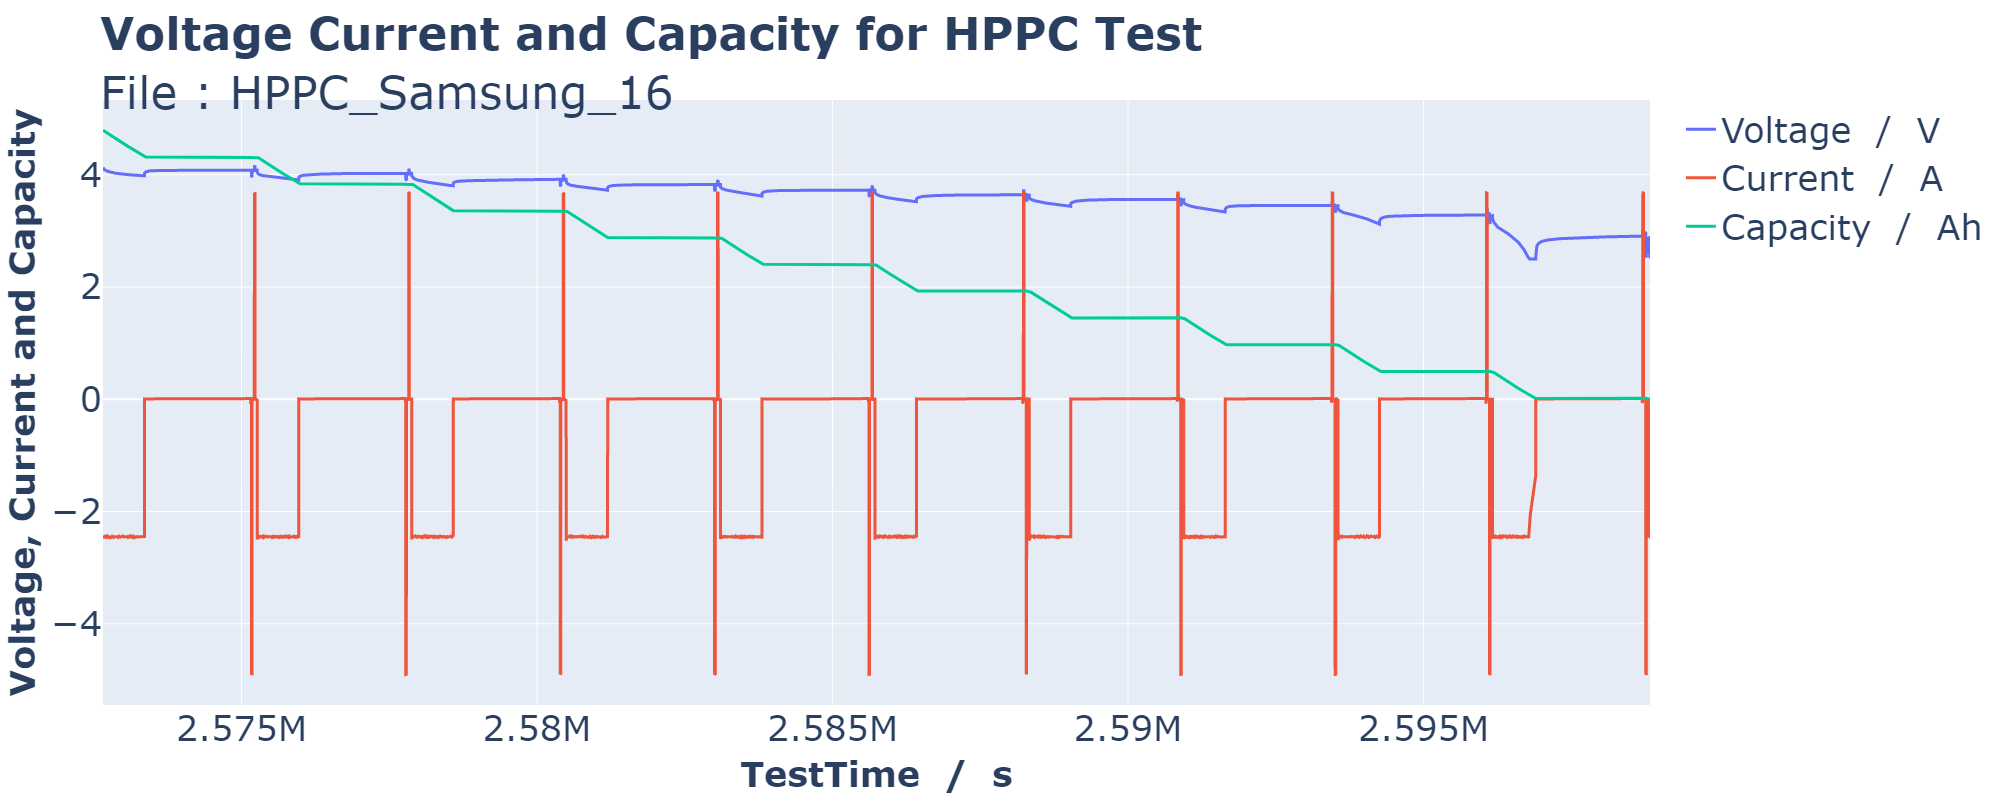

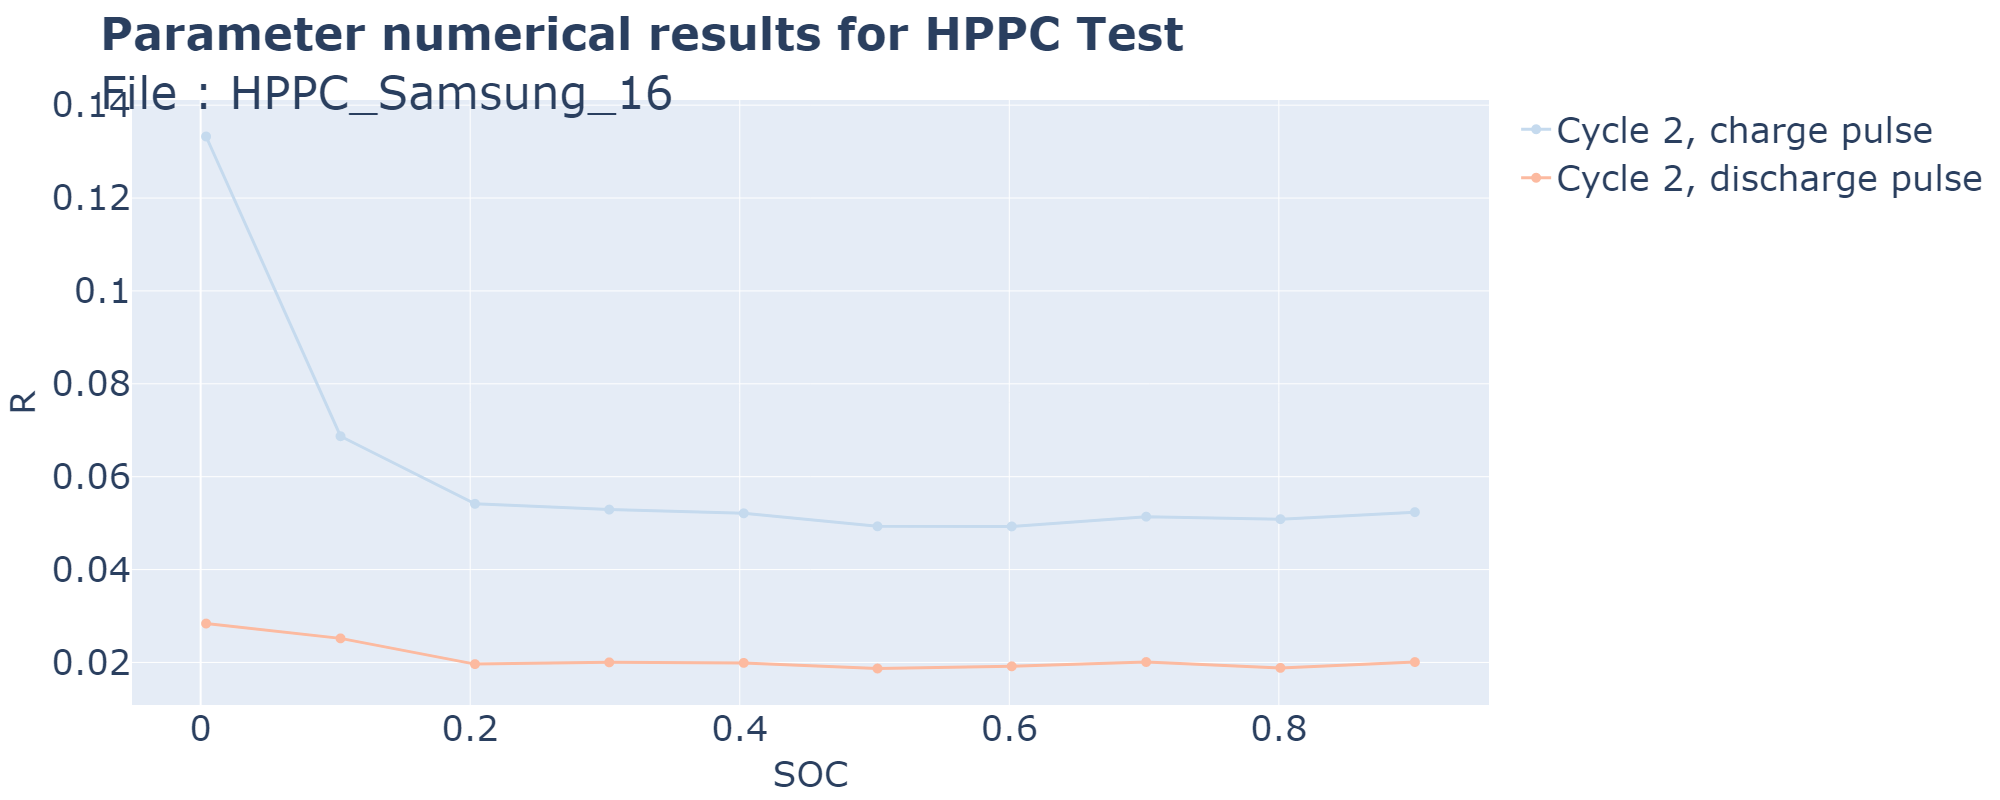

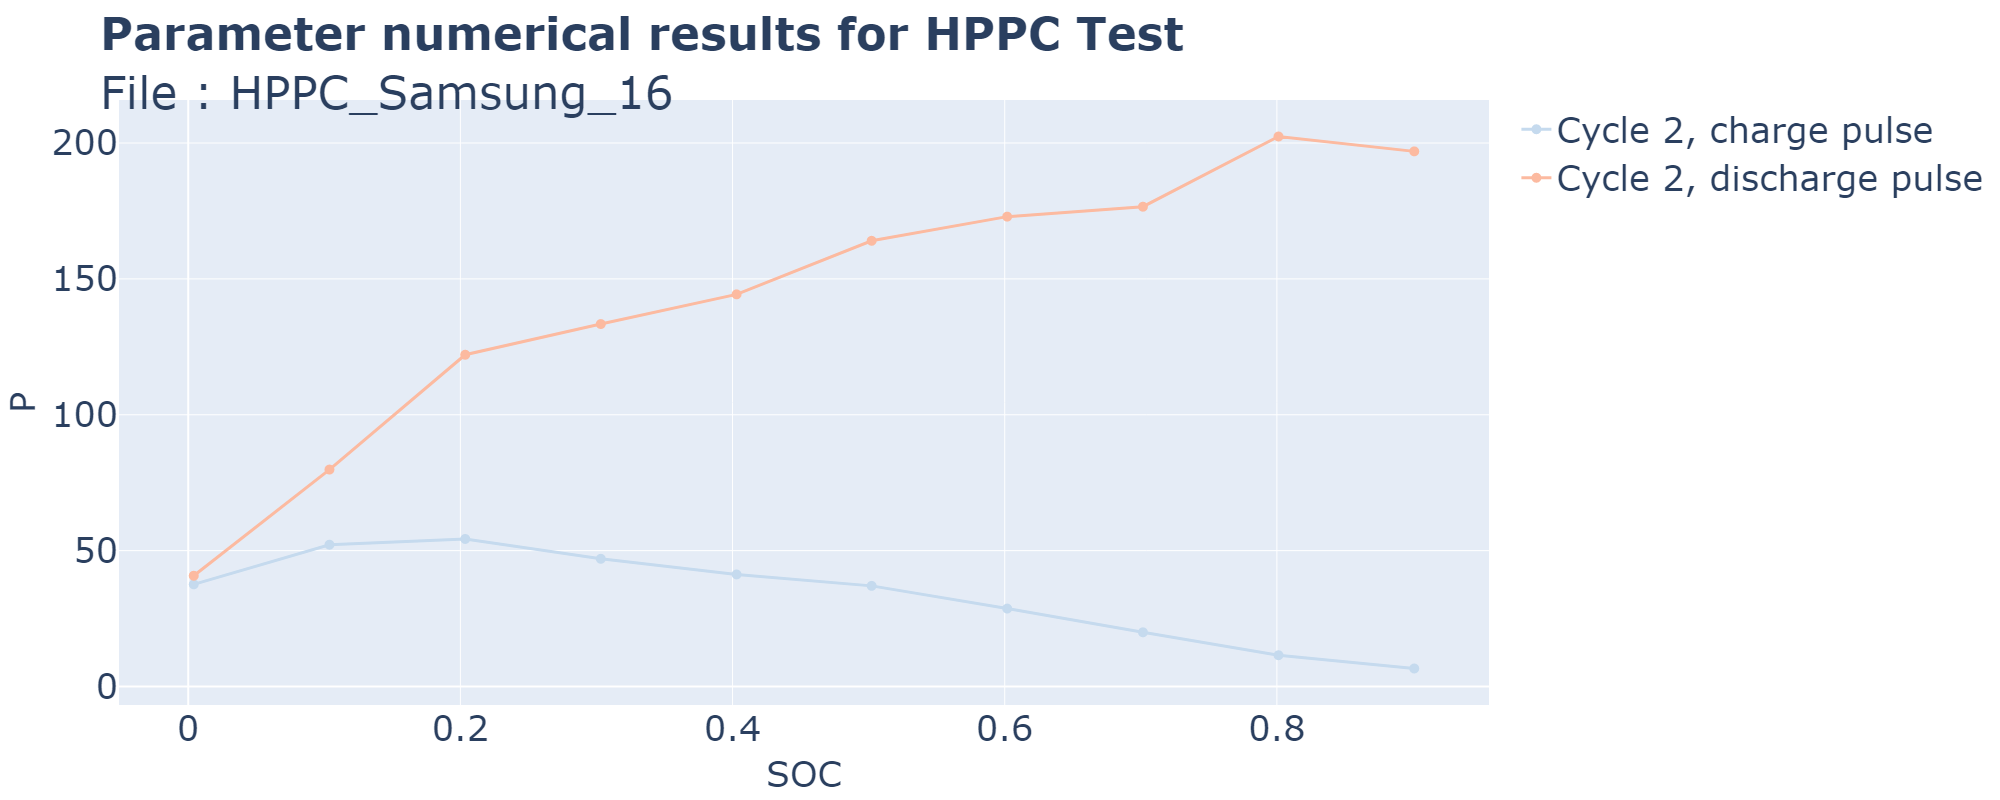

HPPC Time : 3s
Total Time : 149s


In [ ]:
def my_second_example_func(V3, V4, Icharge):
    R_charge = (V4 - V3) / Icharge
    return R_charge

file_path_HPPC = os.path.join('example_file_HPPC.parquet')

column_names = {
    'Time': 'SysTime',
    'E': 'Current',
    ' W': 'Voltage',}
def my_debug_func(df):
    df[['Time', 'ClimaTemp']] = df['Time'].str.extract(r'(.+ \d{2}:\d{2}:\d{2})\.?(\d+)?')
    df["Time"] = pd.to_datetime(df["Time"])
    return df

df, result_dict = process_file(file_path_HPPC, column_names=column_names, debug_func=my_debug_func, my_func_list=[my_second_example_func], png=True)